In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from pandas import IndexSlice as idx
import os
from tqdm import tqdm
from pathlib import Path
import time
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import spearmanr

In [3]:
class FactorBacktester:
    def __init__(self, factor, stock_daily, factor_name="MyFactor", n_groups=10):
        """
        Initialize the backtesting engine, extract close prices,
        and align signal dates with rebalancing dates.
        """
        self.factor = factor
        self.factor_name = factor_name
        self.n_groups = n_groups
        self.group_returns = None
        self.ic_series = None
        
        # Extract close price matrix
        self.price = stock_daily['close'].unstack()
        
        # Preprocess date sequences required for backtesting
        self._prepare_data()

    def _prepare_data(self):
        """
        Identify month-end signal dates and the corresponding
        next-month rebalancing dates, and compute period returns.
        """
        self.factor.index = pd.to_datetime(self.factor.index)
        # Extract the last trading day of each month
        signal_dates = self.factor.groupby(pd.Grouper(freq='ME')).apply(
            lambda x: x.index[-1] if not x.empty else None
        ).dropna()
        signal_dates = pd.DatetimeIndex(signal_dates)
        
        # Determine rebalancing dates (first trading day after each signal date)
        all_dates = self.price.index
        rebalance_dates = []
        for d in signal_dates:
            next_dates = all_dates[all_dates > d]
            if not next_dates.empty:
                rebalance_dates.append(next_dates[0])
        self.rebalance_dates = pd.DatetimeIndex(rebalance_dates)
        
        # Compute holding-period returns
        adj_price = self.price.loc[self.rebalance_dates]
        self.period_ret = adj_price.shift(-1) / adj_price - 1
        
        # Align signals with rebalancing dates
        self.signal_df = self.factor.loc[signal_dates[:len(self.rebalance_dates)]]
        self.signal_df.index = self.rebalance_dates

    def run(self):
        """
        Perform cross-sectional group return calculation
        and Rank IC computation.
        """
        group_rets = []
        ic_list = []
        
        for date in self.rebalance_dates[:-1]:
            s = self.signal_df.loc[date].dropna()
            r = self.period_ret.loc[date].dropna()
            common = s.index.intersection(r.index)
            
            if len(common) < self.n_groups: 
                continue
            
            s, r = s.loc[common], r.loc[common]
            ic_list.append(spearmanr(s, r)[0])
            
            # Grouping logic: lowest factor values in Group 1,
            # highest factor values in Group 10
            labels = range(1, self.n_groups + 1)
            groups = pd.qcut(
                s.rank(method='first', ascending=True),
                self.n_groups,
                labels=labels
            )
            monthly_group_ret = r.groupby(groups, observed=True).mean()
            group_rets.append(monthly_group_ret)
            
        self.group_returns = pd.DataFrame(group_rets, index=self.rebalance_dates[:-1])
        self.ic_series = pd.Series(ic_list, index=self.rebalance_dates[:-1])

    def plot_performance(self):
        """
        Plot cumulative group net value curves and
        the long-short portfolio performance.
        """
        if self.group_returns is None: 
            return
        
        fig, ax1 = plt.subplots(figsize=(12, 6), dpi=300)
        cum_rets = (self.group_returns + 1).cumprod()
        
        # Use a standard color map
        colors = plt.cm.viridis(np.linspace(0, 1, self.n_groups))
        
        for i, col in enumerate(cum_rets.columns):
            ax1.plot(
                cum_rets.index,
                cum_rets[col],
                label=f'Group {col}',
                color=colors[i],
                alpha=0.8
            )
            
        # Plot long-short net value (right axis: G1 - G10)
        ls_cum = (self.group_returns[1] - self.group_returns[self.n_groups] + 1).cumprod()
        ax2 = ax1.twinx()
        ax2.plot(
            ls_cum.index,
            ls_cum,
            color='red',
            linewidth=2,
            label='Long-Short Return (Right Axis)'
        )
        
        # Optimize x-axis date display: show one tick per year
        ax1.xaxis.set_major_locator(mdates.YearLocator())  # Set major ticks to yearly
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as YYYY
        
        ax1.set_ylabel('Cumulative Group Net Value')
        ax2.set_ylabel('Long-Short Net Value', color='black')
        
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='upper left', ncol=2)
        
        plt.title(f"{self.factor_name} {self.n_groups}-Group and Long-Short Portfolio Performance")
        plt.grid(True, axis='y', alpha=0.3)
        plt.show()

In [4]:
def show_factor_metrics(*engines):
    """
    Concatenate metrics from multiple backtesting engines
    and display them in percentage format.
    """
    results = []
    for eng in engines:
        if eng.group_returns is None: 
            continue
        
        # Long-short returns (G1 - G10)
        ls_ret = eng.group_returns[1] - eng.group_returns[eng.n_groups]
        ic_series = eng.ic_series
        cum_ls = (ls_ret + 1).cumprod()
        
        res = {
            "Factor Name": eng.factor_name,
            "Rank IC": ic_series.mean(),
            "Rank ICIR": ic_series.mean() / ic_series.std(),
            "t-value": (ic_series.mean() / ic_series.std()) * np.sqrt(len(ic_series)),
            "Annualized Return": ls_ret.mean() * 12,
            "Annualized Volatility": ls_ret.std() * np.sqrt(12),
            "Information Ratio": (
                (ls_ret.mean() * 12) / (ls_ret.std() * np.sqrt(12))
                if ls_ret.std() != 0 else 0
            ),
            "Monthly Win Rate": (ls_ret > 0).mean(),
            "Maximum Drawdown": (cum_ls.cummax() - cum_ls).max() / cum_ls.cummax().max()
        }
        results.append(res)
    
    df = pd.DataFrame(results)
    
    # Formatting
    fmt_pct = "{:.2%}".format
    fmt_val = "{:.2f}".format
    style_dict = {
        "Rank IC": fmt_pct,
        "Rank ICIR": fmt_val,
        "t-value": fmt_val,
        "Annualized Return": fmt_pct,
        "Annualized Volatility": fmt_pct,
        "Information Ratio": fmt_val,
        "Monthly Win Rate": fmt_pct,
        "Maximum Drawdown": fmt_pct
    }
    
    return df.style.format(style_dict).hide(axis='index')

In [5]:
def neutralize_factor(factor_df, stock_daily):
    """
    Apply MAD-based outlier clipping, industry and market-cap neutralization,
    and cross-sectional standardization to the factor.
    """
    factor_df.index = pd.to_datetime(factor_df.index)
    all_trade_dates = factor_df.index.unique().sort_values()
    
    # Initialize the output matrix
    neutralized_matrix = pd.DataFrame(index=factor_df.index, columns=factor_df.columns)
    
    for d in tqdm(all_trade_dates):
        # 1. Extract the cross-section
        y_raw = factor_df.loc[d].dropna()
        if y_raw.empty: 
            continue
        
        try:
            # Retrieve stock_daily data for the given date (including all stocks)
            daily_data = stock_daily.loc[d]
        except KeyError: 
            continue
            
        # 2. Dynamic filtering: take the intersection and keep stocks with non-NaN industry and market cap
        # Get stock codes present in both datasets
        common_stocks = y_raw.index.intersection(daily_data.index)
        
        # Extract regression features and immediately drop rows with missing industry or market cap
        info = daily_data.loc[common_stocks, ['total_mv', 'industry']].dropna()
        
        # Final regression universe (only stocks remaining in info are used)
        final_stocks = info.index
        if final_stocks.empty: 
            continue
        
        y = y_raw.loc[final_stocks]
        
        # 3. MAD-based outlier clipping
        median = y.median()
        mad = (y - median).abs().median()
        # 4.4478 = 3 * 1.4826
        y_clipped = y.clip(median - 4.4478 * mad, median + 4.4478 * mad)
        
        # 4. Construct regressors X (log market cap + industry dummies)
        X = pd.concat([
            np.log(info.loc[final_stocks, 'total_mv'].astype(float)), 
            pd.get_dummies(info.loc[final_stocks, 'industry'], prefix='ind')
        ], axis=1)
        X = sm.add_constant(X)
        
        # 5. Run OLS and take residuals, then standardize
        # Fit an OLS model; residuals represent factor values net of market-cap and industry effects
        resid = sm.OLS(y_clipped, X.astype(float)).fit().resid
        
        # 6. Cross-sectional standardization (Z-Score)
        neutralized_matrix.loc[d, final_stocks] = (resid - resid.mean()) / resid.std()
            
    return neutralized_matrix.astype(float)

In [6]:
# Load daily price data
stock_daily = pd.read_parquet('/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_daily.parquet',)

# Keep data from 2015-01-01 onward
stock_daily = stock_daily.loc[slice('2015-01-01', None), :]

# Define unit price fields to be adjusted
px_cols = ['open', 'high', 'low', 'close', 'pre_close', 'up_limit', 'down_limit']

# Get the latest adjustment factor for each stock
latest_adj = stock_daily.groupby(level='ts_code')['adj_factor'].transform('last')

# Compute forward-adjustment multiplier
mult = stock_daily['adj_factor'] / latest_adj

# Apply forward adjustment to price fields and keep 2 decimal places
stock_daily[px_cols] = stock_daily[px_cols].mul(mult, axis=0).round(2)

# Compute adjusted price change
stock_daily['change'] = (stock_daily['close'] - stock_daily['pre_close']).round(2)

# Compute adjusted percentage change
stock_daily['pct_chg'] = (stock_daily['change'] / stock_daily['pre_close'] * 100).round(2)

# Sort the index
stock_daily.sort_index(inplace=True)

In [7]:
# Load industry data and restrict to the specified date range
sw_l1_daily = pd.read_parquet('/Users/zhaoweizhi/Desktop/Quant_Research/Data/sw_l1_daily.parquet')
sw_l1_daily = sw_l1_daily.loc[slice('2015-01-01', None), :]

# Extract industry names and constituent lists
industry_lookup = sw_l1_daily[['name', 'con_codes']].copy()

# Explode the constituent list into rows while keeping the original date index
industry_lookup = industry_lookup.explode('con_codes')

# Remove the index level for index codes, keeping only the date level
industry_lookup = industry_lookup.reset_index(level=1, drop=True)

# Append constituent stock codes to the index to match (trade_date, ts_code) structure
industry_lookup = industry_lookup.set_index('con_codes', append=True)
industry_lookup.index.names = ['trade_date', 'ts_code']
industry_lookup.columns = ['industry']

# Drop duplicates to ensure a unique industry mapping for each (date, stock)
industry_lookup = industry_lookup[~industry_lookup.index.duplicated(keep='first')]

# Join industry information into the daily stock table via index alignment
stock_daily = stock_daily.join(industry_lookup, how='left')

In [8]:
stock_daily

open    high     low   close  pre_close  change  \
trade_date ts_code                                                        
2015-01-05 000001.SZ    8.44    8.60    8.24    8.46       8.36    0.10   
           000002.SZ    9.76   10.38    9.65   10.12       9.43    0.69   
           000004.SZ   15.58   15.90   15.30   15.69      15.57    0.12   
           000006.SZ    5.68    5.91    5.61    5.66       5.64    0.02   
           000007.SZ    9.67    9.86    9.50    9.68       9.73   -0.05   
...                      ...     ...     ...     ...        ...     ...   
2026-01-09 920978.BJ   36.06   36.75   35.78   36.15      36.15    0.00   
           920981.BJ   34.07   34.59   33.78   34.23      34.07    0.16   
           920982.BJ  235.99  237.31  234.18  236.70     235.91    0.79   
           920985.BJ    7.57    7.68    7.48    7.55       7.55    0.00   
           920992.BJ   18.59   18.59   18.14   18.21      18.34   -0.13   

                      pct_chg         vol        amount  up_limit  ...  \
trade_date ts_code                                                 ...   
2015-01-05 000001.SZ     1.20  2860436.43  4.565388e+06      9.20  ...   
           000002.SZ     7.32  6560835.70  9.700712e+06     10.38  ...   
           000004.SZ     0.77    28095.12  4.374656e+04     17.13  ...   
           000006.SZ     0.35  1078647.12  7.753464e+05      6.21  ...   
           000007.SZ    -0.51    28415.72  4.123256e+04     10.70  ...   
...                       ...         ...           ...       ...  ...   
2026-01-09 920978.BJ     0.00    32253.76  1.168228e+05     46.99  ...   
           920981.BJ     0.47    13522.64  4.622027e+04     44.29  ...   
           920982.BJ     0.33     9061.73  2.137324e+05    306.68  ...   
           920985.BJ     0.00    47200.60  3.571220e+04      9.81  ...   
           920992.BJ    -0.71    14015.74  2.560948e+04     23.84  ...   

                      float_share   free_share      total_mv       circ_mv  \
trade_date ts_code                                                           
2015-01-05 000001.SZ  983671.2150  469043.8146  1.830268e+07  1.575841e+07   
           000002.SZ  967191.3090  802641.8370  1.642341e+07  1.442082e+07   
           000004.SZ    8387.5459    6196.0792  1.317594e+05  1.316006e+05   
           000006.SZ  133889.7143   81253.4178  9.557965e+05  9.479392e+05   
           000007.SZ   20581.3141   16202.0203  3.353617e+05  2.988407e+05   
...                           ...          ...           ...           ...   
2026-01-09 920978.BJ   10093.4948    9461.0882  6.508029e+05  3.648798e+05   
           920981.BJ    3730.9618    2456.8096  2.617500e+05  1.277108e+05   
           920982.BJ    5490.5088    4371.6612  2.723597e+06  1.299603e+06   
           920985.BJ   21931.7859   13496.7859  2.336545e+05  1.655850e+05   
           920992.BJ    4739.8177    2789.8177  1.761470e+05  8.631208e+04   

                      adj_factor  is_st  suspend_timing  suspend_type  \
trade_date ts_code                                                      
2015-01-05 000001.SZ     71.0540      0            None             N   
           000002.SZ    123.2960      0            None             N   
           000004.SZ      4.0640      0            None             N   
           000006.SZ     31.7800      0            None             N   
           000007.SZ      5.5210      0            None             N   
...                          ...    ...             ...           ...   
2026-01-09 920978.BJ      1.2885      0            None             N   
           920981.BJ      1.4343      0            None             N   
           920982.BJ      4.2831      0            None             N   
           920985.BJ      1.6280      0            None             N   
           920992.BJ      1.4932      0            None             N   

                      listed_days  industry  
trade_date ts_code                           
2015-01-05 000001.SZ        

## “Tide” Factor Construction and Stock Selection Performance Test

### Definition of “Tide”

We define “rising tide” and “falling tide” by examining the intraday peaks and troughs of individual stocks’ minute-level trading volume. The procedure is as follows:

1. We exclude opening and closing periods and only consider intraday minute-level data. To mitigate the impact of isolated outliers, we first compute, for each minute, the sum of its trading volume and the trading volumes of the preceding and following four minutes (a total of nine minutes). This sum is defined as the **“neighborhood volume”** for that minute.

2. Suppose the maximum neighborhood volume occurs at minute $ t $. This minute is referred to as the **“peak moment.”**

3. Within the interval from minute 5 to minute $ t-1 $, the minute at which the neighborhood volume reaches its minimum is denoted as minute $ m $. The neighborhood volume at this minute is $ V_m $, and the closing price is $ C_m $. This minute is referred to as the **“rising tide moment.”** The process from the rising tide moment to the peak moment is defined as the **“rising tide.”**

4. Within the interval from minute $ t+1 $ to minute 233, the minute at which the neighborhood volume reaches its minimum is denoted as minute $ n $. The neighborhood volume at this minute is $ V_n $, and the closing price is $ C_n $. This minute is referred to as the **“falling tide moment.”** The process from the peak moment to the falling tide moment is defined as the **“falling tide.”**

5. The entire process from the rising tide moment to the falling tide moment is defined as one complete **“tide.”**

---

### Price Change Rate During the “Tide” Process

We next examine the price change rate over the tide process and construct the **“Full Tide”** factor. The procedure is as follows:

1. According to the above definitions, the rising tide moment occurs at minute $ m $ with closing price $ C_m $, and the falling tide moment occurs at minute $ n $ with closing price $ C_n $.

2. The total price change over the entire tide process is given by:
   $$
   \frac{C_n - C_m}{C_m}.
   $$

3. The price change rate over the full tide process is further defined as:
   $$
   \frac{C_n - C_m}{C_m} / (n - m).
   $$
   This measure is used as a proxy for the daily intensity of investors’ willingness to buy or sell the stock.

4. We compute the average of this price change rate over the most recent 20 trading days and define it as the **“Full Tide” factor.**

In [9]:
# Path settings
minute_data_path = '/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_1min/'
all_ts_codes = stock_daily.index.get_level_values('ts_code').unique()

# Collect each stock's "full tide (20-day mean)" series and concat at the end
factor_dict = {}

# Loop through all stocks and show progress on a single line
for idx, ts_code in enumerate(all_ts_codes, 1):
    print(f"\rProcessing {idx}/{len(all_ts_codes)} stocks: {ts_code}          ", end="")

    file_path = os.path.join(minute_data_path, f"{ts_code}.parquet")
    if not os.path.exists(file_path):
        continue

    # Read data and keep records from 2015 onward
    df_min = pd.read_parquet(file_path)
    df_min = df_min.loc['2015-01-01':].copy()
    if df_min.empty:
        continue

    # Forward adjustment for minute-level prices
    latest_adj = df_min['adj_factor'].iloc[-1]
    mult = df_min['adj_factor'] / latest_adj
    for col in ['close', 'open', 'high', 'low']:
        df_min[col] = (df_min[col] * mult).round(2)

    # Remove the first bar of each day (9:30) and the last 3 bars (14:58-15:00)
    df_min = df_min.groupby(level='trade_date', group_keys=False).apply(lambda x: x.iloc[1:-3])
    if df_min.empty:
        continue

    # ---------------------------
    # Compute: daily "full tide" price change rate (Cn-Cm)/Cm/(n-m)
    # ---------------------------
    daily_rate = {}

    for trade_date, x in df_min.groupby(level='trade_date'):
        # Intraday minute series (keep original order; usually already sorted by trade_time)
        if x.shape[0] < 9:
            continue

        # 9-minute "neighborhood volume": centered rolling sum
        neigh_vol = x['vol'].rolling(window=9, center=True, min_periods=9).sum()
        neigh_arr = neigh_vol.to_numpy()

        valid_pos = np.where(~np.isnan(neigh_arr))[0]
        if valid_pos.size == 0:
            continue

        # To match descriptions like "minute 5 to minute 233": search only within the range with a full 9-minute neighborhood
        start_pos = valid_pos[0]
        end_pos = valid_pos[-1]
        if end_pos - start_pos < 2:  # Need at least one point before and after t
            continue

        # Peak time t: maximum neighborhood volume
        t_pos = valid_pos[np.nanargmax(neigh_arr[valid_pos])]

        # Rising-tide time m: minimum neighborhood volume within [start_pos, t_pos-1]
        if t_pos <= start_pos:
            continue
        left_rng = np.arange(start_pos, t_pos)
        m_pos = left_rng[np.nanargmin(neigh_arr[left_rng])]

        # Falling-tide time n: minimum neighborhood volume within [t_pos+1, end_pos]
        if t_pos >= end_pos:
            continue
        right_rng = np.arange(t_pos + 1, end_pos + 1)
        if right_rng.size == 0:
            continue
        n_pos = right_rng[np.nanargmin(neigh_arr[right_rng])]

        # Approximate (n-m) by the difference in minute positions (one row per minute)
        nm = int(n_pos - m_pos)
        if nm <= 0:
            continue

        # Corresponding close prices Cm, Cn
        close_arr = x['close'].to_numpy()
        Cm = close_arr[m_pos]
        Cn = close_arr[n_pos]
        if Cm == 0 or np.isnan(Cm) or np.isnan(Cn):
            continue

        rate = (Cn - Cm) / Cm / nm
        daily_rate[trade_date] = rate

    if len(daily_rate) == 0:
        continue

    s_rate = pd.Series(daily_rate).sort_index()

    # 20-day mean as the "full tide" factor
    s_factor = s_rate.rolling(window=20, min_periods=20).mean()

    factor_dict[ts_code] = s_factor

print("\nConcatenating factor...")

# Final factor: index is trade_date, columns are stocks
factor_full_tide = pd.concat(factor_dict, axis=1)
factor_full_tide.index.name = 'trade_date'
factor_full_tide.columns.name = 'ts_code'

Processing 5702/5702 stocks: 603402.SH          
Concatenating factor...


In [10]:
# Drop rows that are entirely NaN
factor_full_tide.dropna(how='all', axis=0, inplace=True)
# Apply MAD-based outlier clipping, industry and market-cap neutralization,
# and cross-sectional standardization to the factor
factor_full_tide_neutralized = neutralize_factor(factor_full_tide, stock_daily) 

100%|██████████| 2660/2660 [00:23<00:00, 113.87it/s]


In [11]:
factor_full_tide_neutralized

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,688802.SH,001325.SZ,688807.SH,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-02,NaN,NaN,0.267547,NaN,NaN,NaN,NaN,NaN,-0.122684,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,NaN,NaN,0.235792,-0.373869,NaN,NaN,NaN,NaN,-0.589139,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-04,NaN,NaN,-0.013481,-0.482010,NaN,0.329053,0.304741,0.575701,-0.600571,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-05,NaN,NaN,0.202050,NaN,0.125609,0.526760,NaN,0.976819,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05,NaN,-0.241229,-0.643645,NaN,0.859174,-0.699661,-1.025558,-0.521604,0.987316,0.506065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-06,-0.096160,0.054817,-0.941569,-1.512364,0.602276,0.008661,NaN,NaN,0.476271,1.037006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-07,-0.179259,-0.224660,-0.953473,NaN,NaN,NaN,-1.197440,NaN,-0.232785,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Factor Name,Rank IC,Rank ICIR,t-value,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Maximum Drawdown
Full Tide Factor,-7.27%,-1.05,-12.04,25.25%,10.92%,2.31,78.63%,7.75%


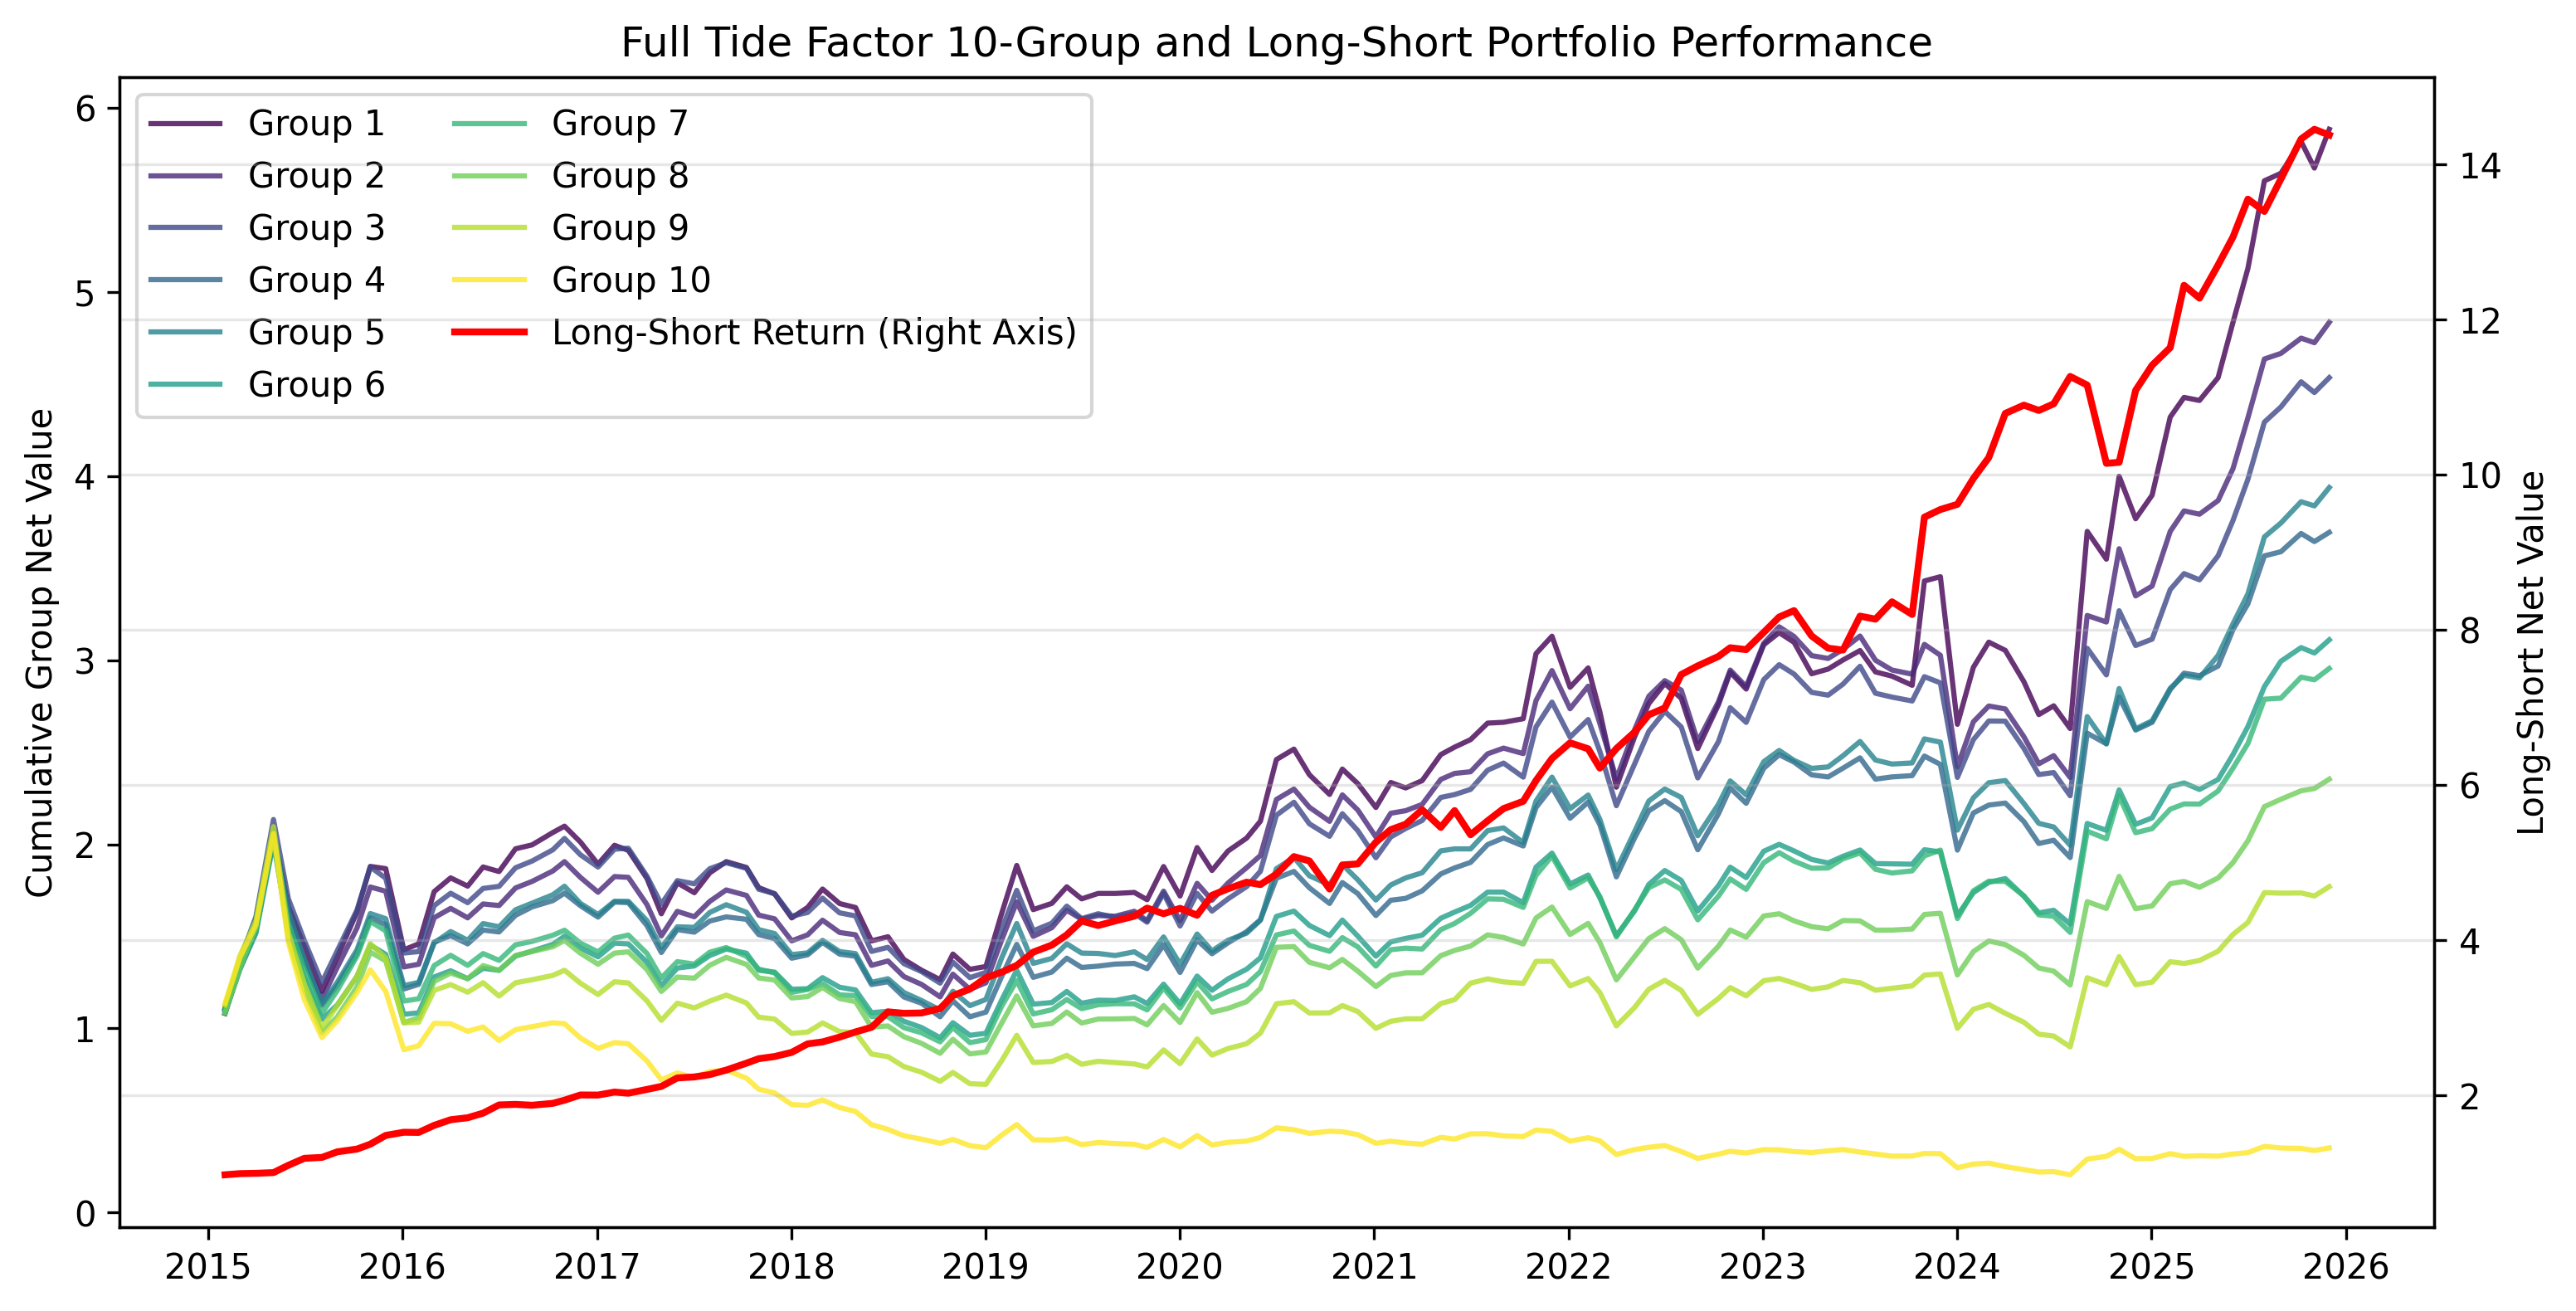

In [12]:
e1 = FactorBacktester(
    factor_full_tide_neutralized,
    stock_daily,
    factor_name='Full Tide Factor'
)
e1.run() 

summary = show_factor_metrics(e1)
display(summary)

e1.plot_performance()

### Strength Decomposition of the “Tide” Process

#### (1) “Strong Half-Tide” and “Weak Half-Tide”

We next examine the intensity embedded in the “rising tide” and “falling tide” processes. Taking the peak moment as the dividing point, we decompose a complete tide into two “half-tides” and construct the **Strong Half-Tide** factor and the **Weak Half-Tide** factor. The procedure is as follows:

1. According to the above definitions, the neighborhood volume at the rising tide moment is denoted as $ V_m $, and the neighborhood volume at the falling tide moment is denoted as $ V_n $.

2. If $ V_m < V_n $, the starting point of the rising tide is lower, implying that a stronger force is required to drive the rising tide. We therefore define the **rising tide** as the **strong half-tide**, and correspondingly define the falling tide as the **weak half-tide**.

3. Conversely, if $ V_m > V_n $, the ending point of the falling tide is lower, implying that a stronger force is required to drive the falling tide. In this case, we define the **falling tide** as the **strong half-tide**, and correspondingly define the rising tide as the **weak half-tide**.

---

#### (2) Construction of the “Strong Half-Tide” Factor

We argue that the strong half-tide spans a wider range of trading volume and requires greater driving force, and therefore contains a higher density of information, which may be more effective in predicting future returns. Based on this intuition, we construct the **Strong Half-Tide** factor as follows:

1. Similar to the construction of the Full Tide factor, we first compute the price change over the strong half-tide by calculating the return between its starting and ending closing prices.

2. We then divide this return by the duration (in minutes) of the strong half-tide to obtain the price change rate of the portion of the tide driven by stronger forces. This measure is used as a proxy for investor trading enthusiasm during periods of relatively stronger buying or selling pressure.

3. Finally, we compute the average of this price change rate over the most recent 20 trading days and define it as the **Strong Half-Tide** factor.

---

#### (3) Construction of the “Weak Half-Tide” Factor

Using the same framework, we further examine periods characterized by relatively subdued trading enthusiasm, referred to as the **Weak Half-Tide**, in order to extract information embedded in these calmer trading intervals. We first compute the price change rate during the weak half-tide process. The procedure is as follows:

1. Analogous to the construction of the Strong Half-Tide factor, we compute the return between the starting and ending closing prices of the weak half-tide.

2. We then divide this return by the duration (in minutes) of the weak half-tide to obtain the price change rate during periods associated with relatively weaker driving forces. This measure serves as a proxy for investor trading enthusiasm during periods of lower intensity.

3. We characterize the weak half-tide factor in two different ways. First, we compute the average price change rate within the weak half-tide over the most recent 20 trading days and define it as the **Aggressive Weak Half-Tide** factor. Second, we compute the standard deviation of the price change rate over the most recent 20 trading days and define it as the **Stable Weak Half-Tide** factor.


In [13]:
minute_data_path = '/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_1min/'
all_ts_codes = stock_daily.index.get_level_values('ts_code').unique()

factor_dict = {}

for idx, ts_code in enumerate(all_ts_codes, 1):
    print(f"\rProcessing {idx}/{len(all_ts_codes)} stocks: {ts_code}          ", end="")

    file_path = os.path.join(minute_data_path, f"{ts_code}.parquet")
    if not os.path.exists(file_path):
        continue

    df_min = pd.read_parquet(file_path)
    df_min = df_min.loc['2015-01-01':].copy()
    if df_min.empty:
        continue

    # Forward adjustment
    latest_adj = df_min['adj_factor'].iloc[-1]
    mult = df_min['adj_factor'] / latest_adj
    for col in ['close', 'open', 'high', 'low']:
        df_min[col] = (df_min[col] * mult).round(2)

    # Remove the first bar at the open & the last 3 bars at the close
    df_min = df_min.groupby(level='trade_date', group_keys=False).apply(lambda x: x.iloc[1:-3])
    if df_min.empty:
        continue

    daily_rate = {}

    for trade_date, x in df_min.groupby(level='trade_date'):
        if x.shape[0] < 9:
            continue

        # 9-minute neighborhood volume
        neigh_arr = (
            x['vol']
            .rolling(window=9, center=True, min_periods=9)
            .sum()
            .to_numpy()
        )

        valid_pos = np.where(~np.isnan(neigh_arr))[0]
        if valid_pos.size == 0:
            continue

        start_pos, end_pos = valid_pos[0], valid_pos[-1]

        # Peak time t
        t_pos = valid_pos[np.nanargmax(neigh_arr[valid_pos])]

        # Rising-tide start m
        if t_pos <= start_pos:
            continue
        left_rng = np.arange(start_pos, t_pos)
        m_pos = left_rng[np.nanargmin(neigh_arr[left_rng])]

        # Falling-tide end n
        if t_pos >= end_pos:
            continue
        right_rng = np.arange(t_pos + 1, end_pos + 1)
        if right_rng.size == 0:
            continue
        n_pos = right_rng[np.nanargmin(neigh_arr[right_rng])]

        # Corresponding neighborhood volumes
        Vm = neigh_arr[m_pos]
        Vn = neigh_arr[n_pos]

        close_arr = x['close'].to_numpy()

        # -----------------------------
        # Strong half-tide identification
        # -----------------------------
        if Vm < Vn:
            # Rising tide is the strong half-tide: m -> t
            start, end = m_pos, t_pos
        elif Vm > Vn:
            # Falling tide is the strong half-tide: t -> n
            start, end = t_pos, n_pos
        else:
            continue

        duration = end - start
        if duration <= 0:
            continue

        C_start = close_arr[start]
        C_end = close_arr[end]
        if C_start == 0 or np.isnan(C_start) or np.isnan(C_end):
            continue

        rate = (C_end - C_start) / C_start / duration
        daily_rate[trade_date] = rate

    if not daily_rate:
        continue

    s_rate = pd.Series(daily_rate).sort_index()

    # 20-day mean: strong half-tide factor
    s_factor = s_rate.rolling(window=20, min_periods=20).mean()

    factor_dict[ts_code] = s_factor

print("\nConcatenating strong half-tide factor...")

factor_strong_half_tide = pd.concat(factor_dict, axis=1)
factor_strong_half_tide.index.name = 'trade_date'
factor_strong_half_tide.columns.name = 'ts_code'

Processing 5702/5702 stocks: 603402.SH          
Concatenating strong half-tide factor...


In [14]:
# Drop rows that are entirely NaN
factor_strong_half_tide.dropna(how='all', axis=0, inplace=True)
# Apply MAD-based outlier clipping, industry and market-cap neutralization,
# and cross-sectional standardization to the factor
factor_strong_half_tide_neutralized = neutralize_factor(factor_strong_half_tide, stock_daily) 

100%|██████████| 2660/2660 [00:24<00:00, 107.40it/s]


In [15]:
factor_strong_half_tide_neutralized

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,688802.SH,001325.SZ,688807.SH,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-02,NaN,NaN,0.717907,NaN,NaN,NaN,NaN,NaN,0.486360,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,NaN,NaN,0.420828,-2.144685,NaN,NaN,NaN,NaN,0.754684,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-04,NaN,NaN,-0.366315,-1.998580,NaN,-0.369530,-0.293448,0.136092,0.813931,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-05,NaN,NaN,-0.400692,NaN,-0.989021,-0.047680,NaN,0.806356,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05,NaN,0.388207,0.663988,NaN,0.493227,-0.610063,-0.869354,-0.421437,1.164490,1.036174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-06,0.080145,0.342274,0.427819,-1.677465,0.341634,-0.558548,NaN,NaN,0.998173,1.185498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-07,0.114614,0.186516,0.485963,NaN,NaN,NaN,-0.926319,NaN,0.460785,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Factor Name,Rank IC,Rank ICIR,t-value,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Maximum Drawdown
Strong Half-Tide Factor,-4.90%,-1.26,-14.48,19.25%,6.47%,2.98,80.15%,2.66%


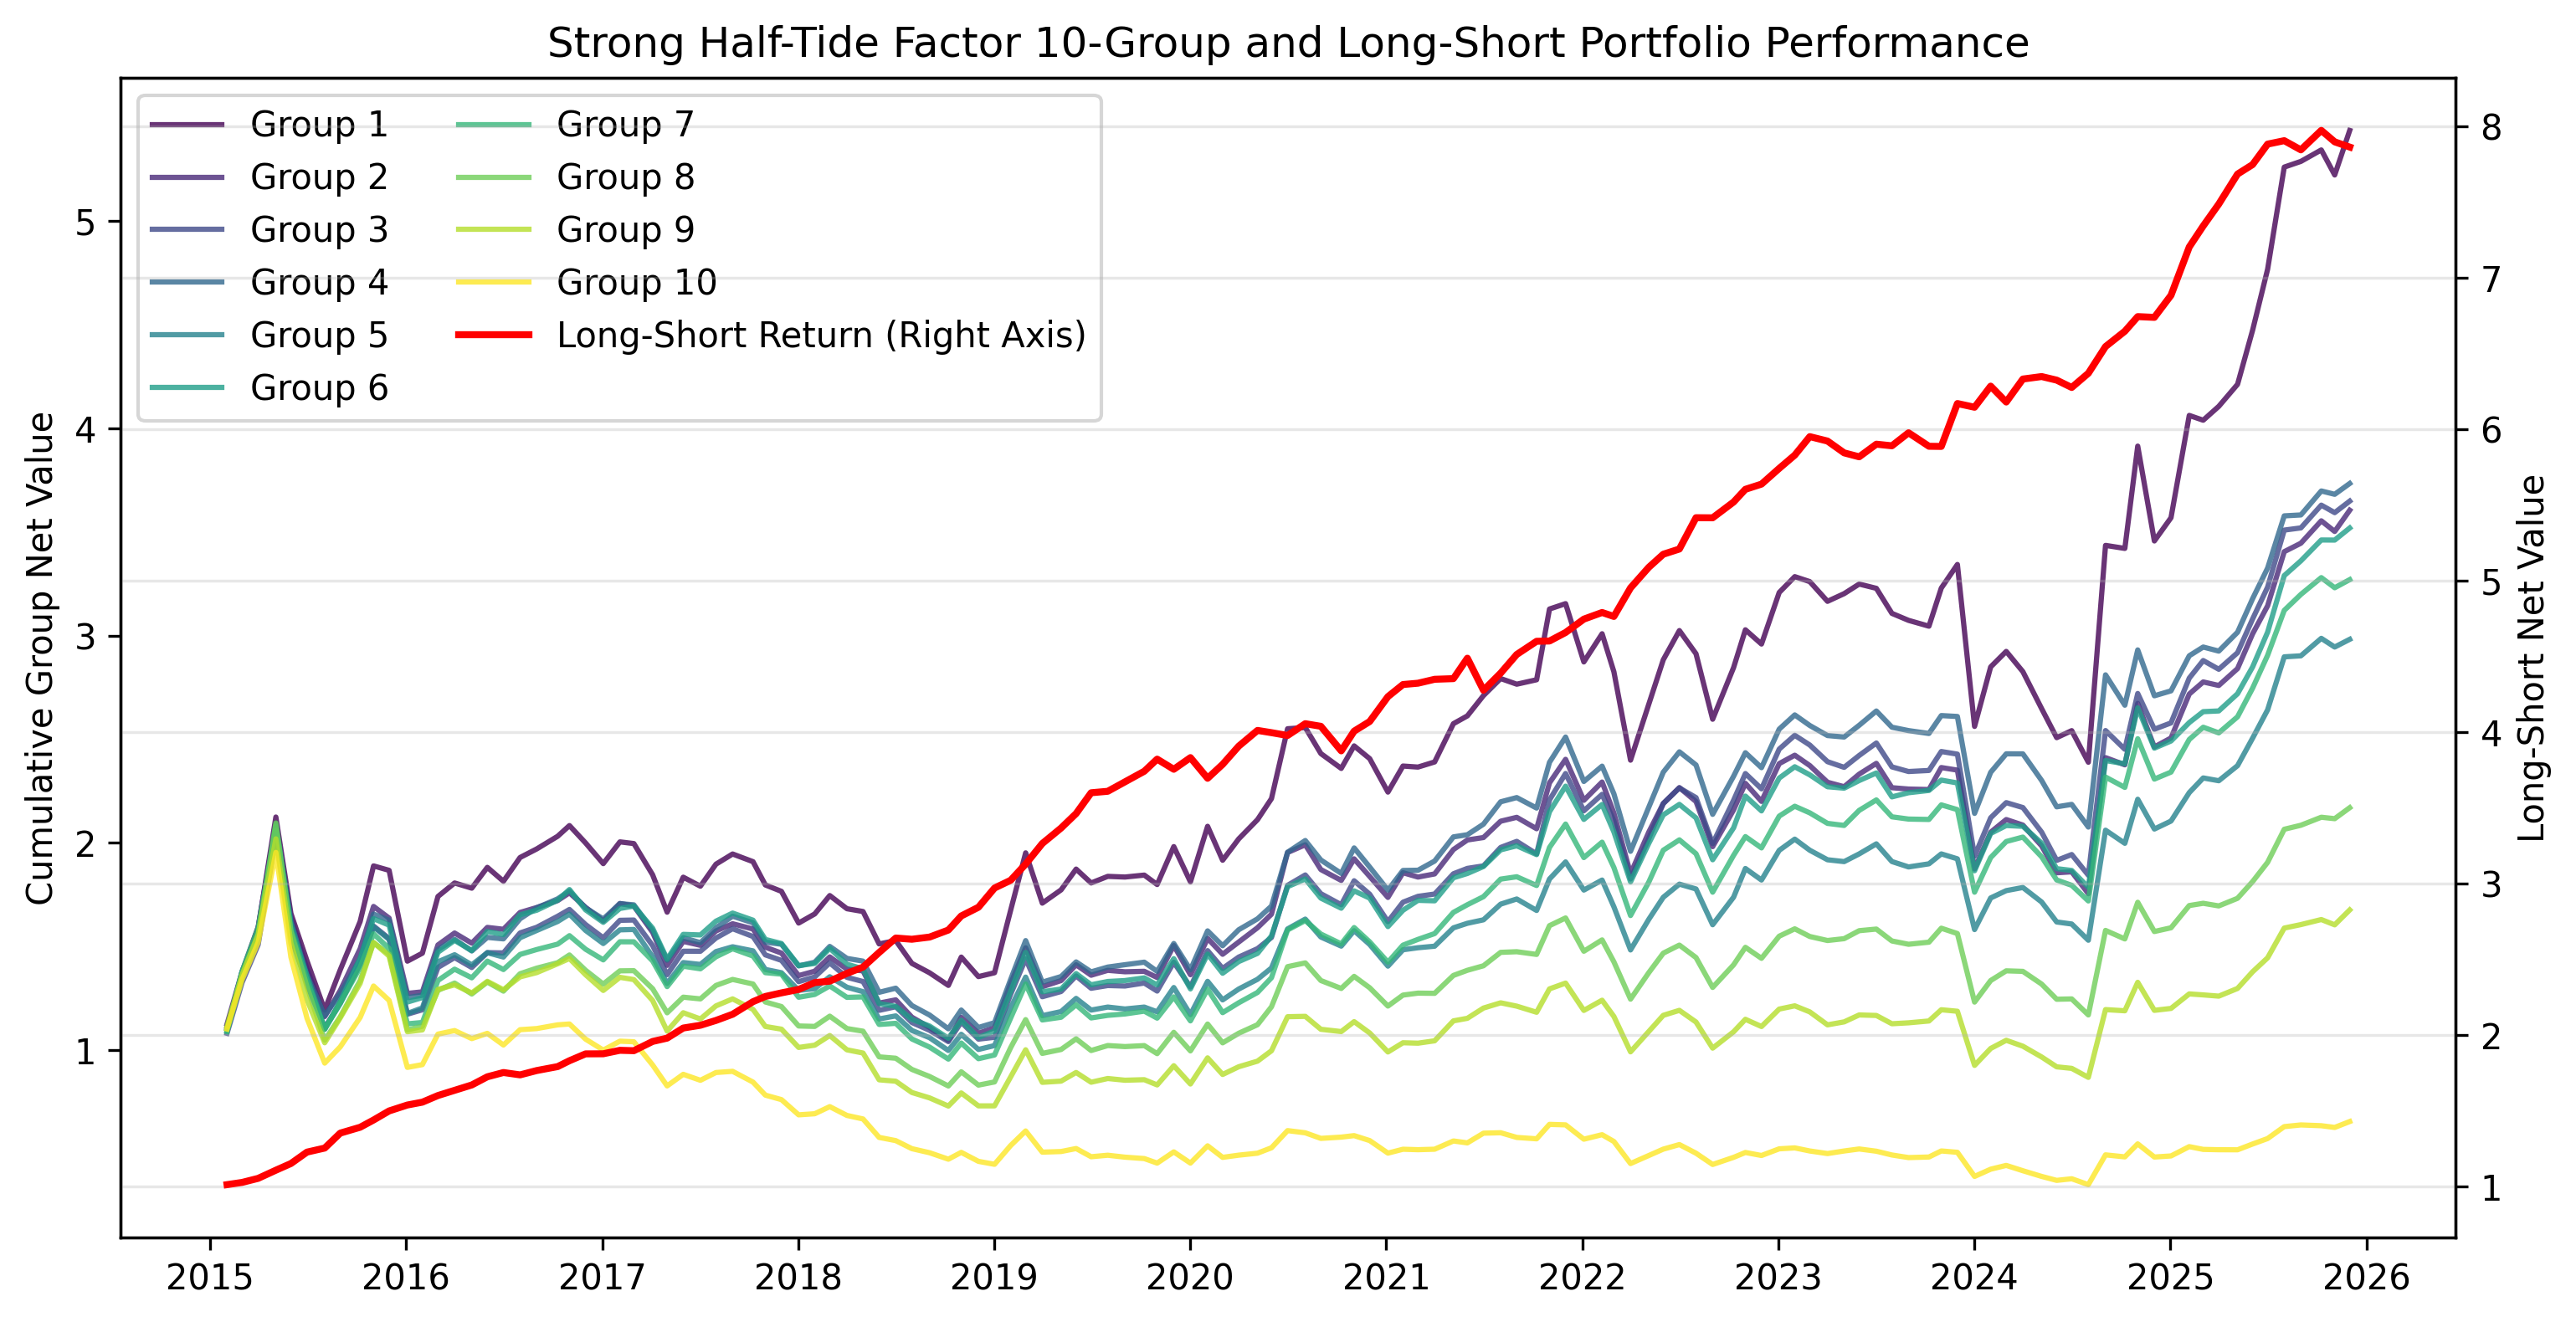

In [17]:
e2 = FactorBacktester(
    factor_strong_half_tide_neutralized,
    stock_daily,
    factor_name='Strong Half-Tide Factor'
)
e2.run() 

summary = show_factor_metrics(e2)
display(summary)

e2.plot_performance()

In [19]:
minute_data_path = '/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_1min/'
all_ts_codes = stock_daily.index.get_level_values('ts_code').unique()

factor_mean_dict = {}   # Aggressive weak half-tide (20-day mean)
factor_std_dict = {}    # Stable weak half-tide (20-day standard deviation)

for idx, ts_code in enumerate(all_ts_codes, 1):
    print(f"\rProcessing {idx}/{len(all_ts_codes)} stocks: {ts_code}          ", end="")

    file_path = os.path.join(minute_data_path, f"{ts_code}.parquet")
    if not os.path.exists(file_path):
        continue

    df_min = pd.read_parquet(file_path)
    df_min = df_min.loc['2015-01-01':].copy()
    if df_min.empty:
        continue

    # Forward adjustment
    latest_adj = df_min['adj_factor'].iloc[-1]
    mult = df_min['adj_factor'] / latest_adj
    for col in ['close', 'open', 'high', 'low']:
        df_min[col] = (df_min[col] * mult).round(2)

    # Remove the first bar at the open & the last 3 bars at the close
    df_min = df_min.groupby(level='trade_date', group_keys=False).apply(lambda x: x.iloc[1:-3])
    if df_min.empty:
        continue

    daily_rate = {}

    for trade_date, x in df_min.groupby(level='trade_date'):
        if x.shape[0] < 9:
            continue

        neigh_arr = (
            x['vol']
            .rolling(window=9, center=True, min_periods=9)
            .sum()
            .to_numpy()
        )

        valid_pos = np.where(~np.isnan(neigh_arr))[0]
        if valid_pos.size == 0:
            continue

        start_pos, end_pos = valid_pos[0], valid_pos[-1]

        # Peak time
        t_pos = valid_pos[np.nanargmax(neigh_arr[valid_pos])]

        # Rising-tide start
        if t_pos <= start_pos:
            continue
        left_rng = np.arange(start_pos, t_pos)
        m_pos = left_rng[np.nanargmin(neigh_arr[left_rng])]

        # Falling-tide end
        if t_pos >= end_pos:
            continue
        right_rng = np.arange(t_pos + 1, end_pos + 1)
        if right_rng.size == 0:
            continue
        n_pos = right_rng[np.nanargmin(neigh_arr[right_rng])]

        Vm = neigh_arr[m_pos]
        Vn = neigh_arr[n_pos]

        close_arr = x['close'].to_numpy()

        # -----------------------------
        # Weak half-tide identification (the complement of the strong half)
        # -----------------------------
        if Vm < Vn:
            # Rising tide is strong -> falling tide is weak: t -> n
            start, end = t_pos, n_pos
        elif Vm > Vn:
            # Falling tide is strong -> rising tide is weak: m -> t
            start, end = m_pos, t_pos
        else:
            continue

        duration = end - start
        if duration <= 0:
            continue

        C_start = close_arr[start]
        C_end = close_arr[end]
        if C_start == 0 or np.isnan(C_start) or np.isnan(C_end):
            continue

        rate = (C_end - C_start) / C_start / duration
        daily_rate[trade_date] = rate

    if not daily_rate:
        continue

    s_rate = pd.Series(daily_rate).sort_index()

    # Aggressive weak half-tide: 20-day mean
    factor_mean_dict[ts_code] = s_rate.rolling(20, min_periods=20).mean()

    # Stable weak half-tide: 20-day standard deviation
    factor_std_dict[ts_code] = s_rate.rolling(20, min_periods=20).std()

print("\nConcatenating weak half-tide factors...")

factor_aggressive_weak_half_tide = pd.concat(factor_mean_dict, axis=1)
factor_aggressive_weak_half_tide.index.name = 'trade_date'
factor_aggressive_weak_half_tide.columns.name = 'ts_code'

factor_stable_weak_half_tide = pd.concat(factor_std_dict, axis=1)
factor_stable_weak_half_tide.index.name = 'trade_date'
factor_stable_weak_half_tide.columns.name = 'ts_code'

Processing 5702/5702 stocks: 603402.SH          
Concatenating weak half-tide factors...


In [20]:
# Drop rows that are entirely NaN
factor_aggressive_weak_half_tide.dropna(how='all', axis=0, inplace=True)
factor_stable_weak_half_tide.dropna(how='all', axis=0, inplace=True)
# Apply MAD-based outlier clipping, industry and market-cap neutralization,
# and cross-sectional standardization to the factors
factor_aggressive_weak_half_tide_neutralized = neutralize_factor(factor_aggressive_weak_half_tide, stock_daily) 
factor_stable_weak_half_tide_neutralized = neutralize_factor(factor_stable_weak_half_tide, stock_daily) 

100%|██████████| 2660/2660 [00:23<00:00, 113.43it/s]


In [21]:
factor_aggressive_weak_half_tide_neutralized

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,688802.SH,001325.SZ,688807.SH,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-02,NaN,NaN,-0.142000,NaN,NaN,NaN,NaN,NaN,-0.384219,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,NaN,NaN,0.112265,0.249049,NaN,NaN,NaN,NaN,-0.791803,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-04,NaN,NaN,0.052427,0.288683,NaN,-0.235701,-0.744505,0.229829,-0.298928,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-05,NaN,NaN,0.613842,NaN,0.483505,-0.080927,NaN,-0.112454,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05,NaN,0.482360,-1.814720,NaN,0.493839,-0.373008,-0.653487,-0.509979,0.289600,-0.007289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-06,-0.035763,0.522464,-1.923480,-0.775688,0.048297,0.314398,NaN,NaN,-0.068752,0.173919,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-07,-0.234948,0.400477,-0.931007,NaN,NaN,NaN,-0.763690,NaN,-0.109144,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
factor_stable_weak_half_tide_neutralized

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,688802.SH,001325.SZ,688807.SH,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-02,NaN,NaN,-0.763216,NaN,NaN,NaN,NaN,NaN,-0.201546,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,NaN,NaN,-0.800276,-0.298261,NaN,NaN,NaN,NaN,-0.159103,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-04,NaN,NaN,-0.864841,-0.365722,NaN,-0.755638,0.677727,-0.830613,-0.027297,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-05,NaN,NaN,-0.660822,NaN,-0.560646,-0.918360,NaN,-0.948352,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05,NaN,-0.387535,1.588405,NaN,0.022158,-0.695456,-1.379406,-0.486436,-0.117559,-0.185965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-06,-0.296652,-0.425484,1.372064,0.079105,-0.056914,-0.226851,NaN,NaN,-0.376645,-0.280901,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-07,-0.273346,-0.459453,1.016603,NaN,NaN,NaN,-1.439606,NaN,-0.399407,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Factor Name,Rank IC,Rank ICIR,t-value,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Maximum Drawdown
Aggressive Weak Half-Tide Factor,-3.88%,-0.79,-9.04,11.88%,7.92%,1.50,68.70%,11.55%
Stable Weak Half-Tide Factor,-5.78%,-0.71,-8.12,10.10%,9.97%,1.01,63.36%,14.86%


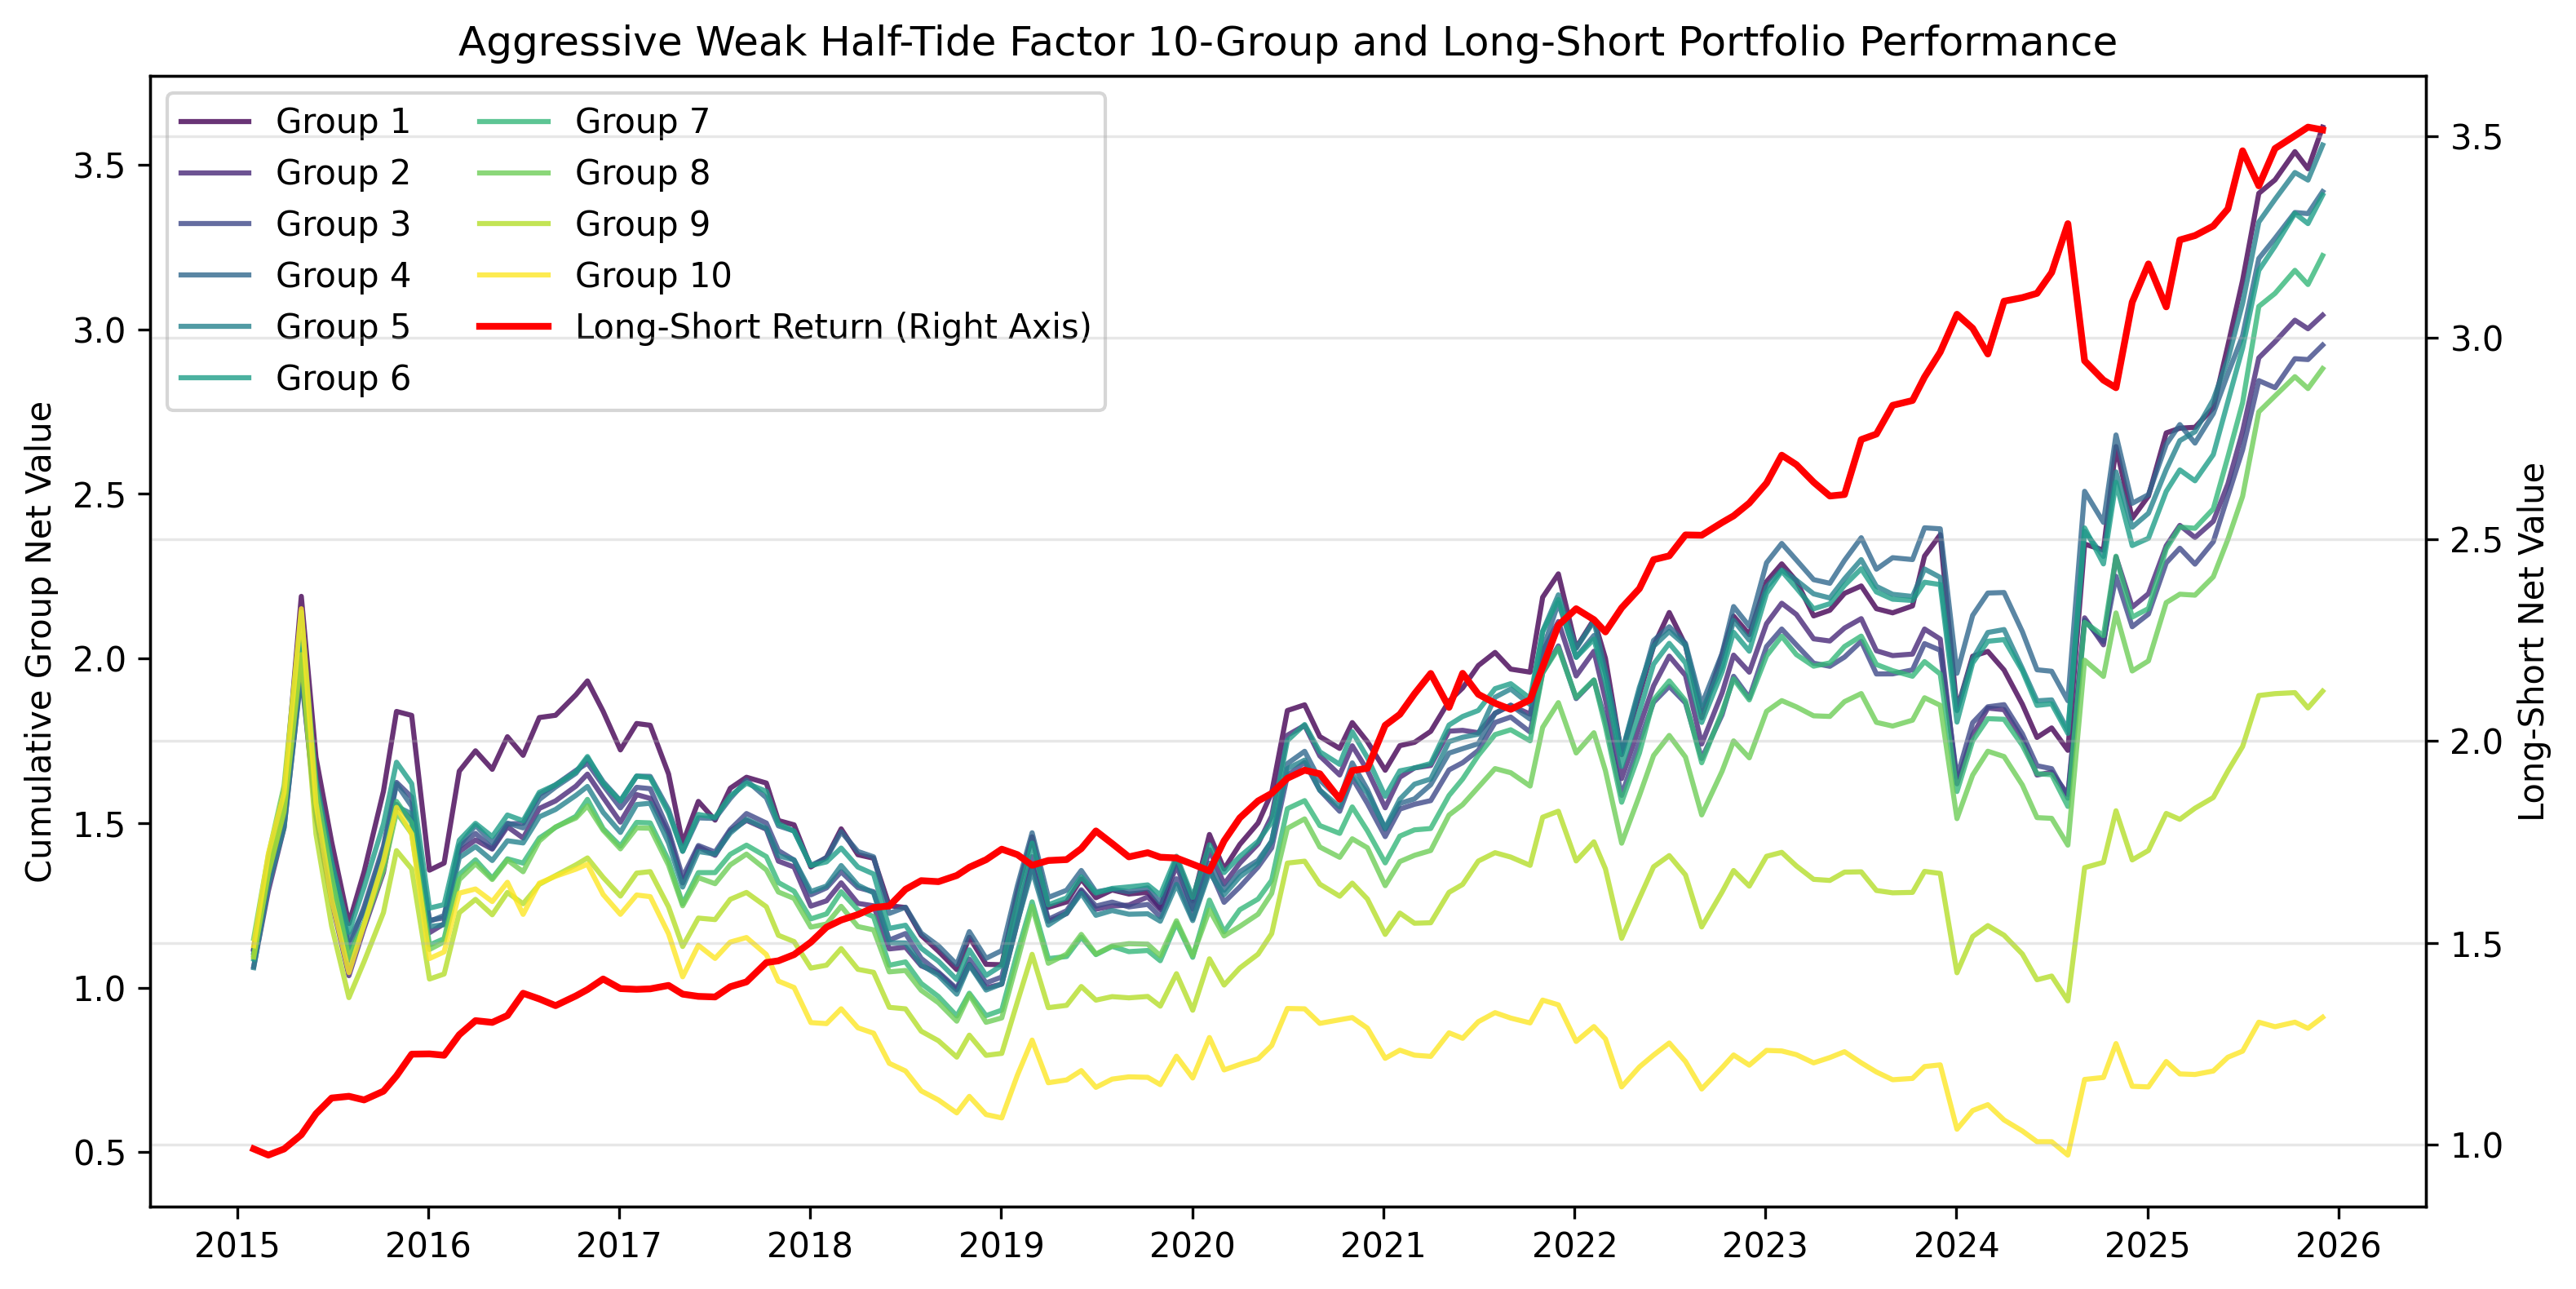

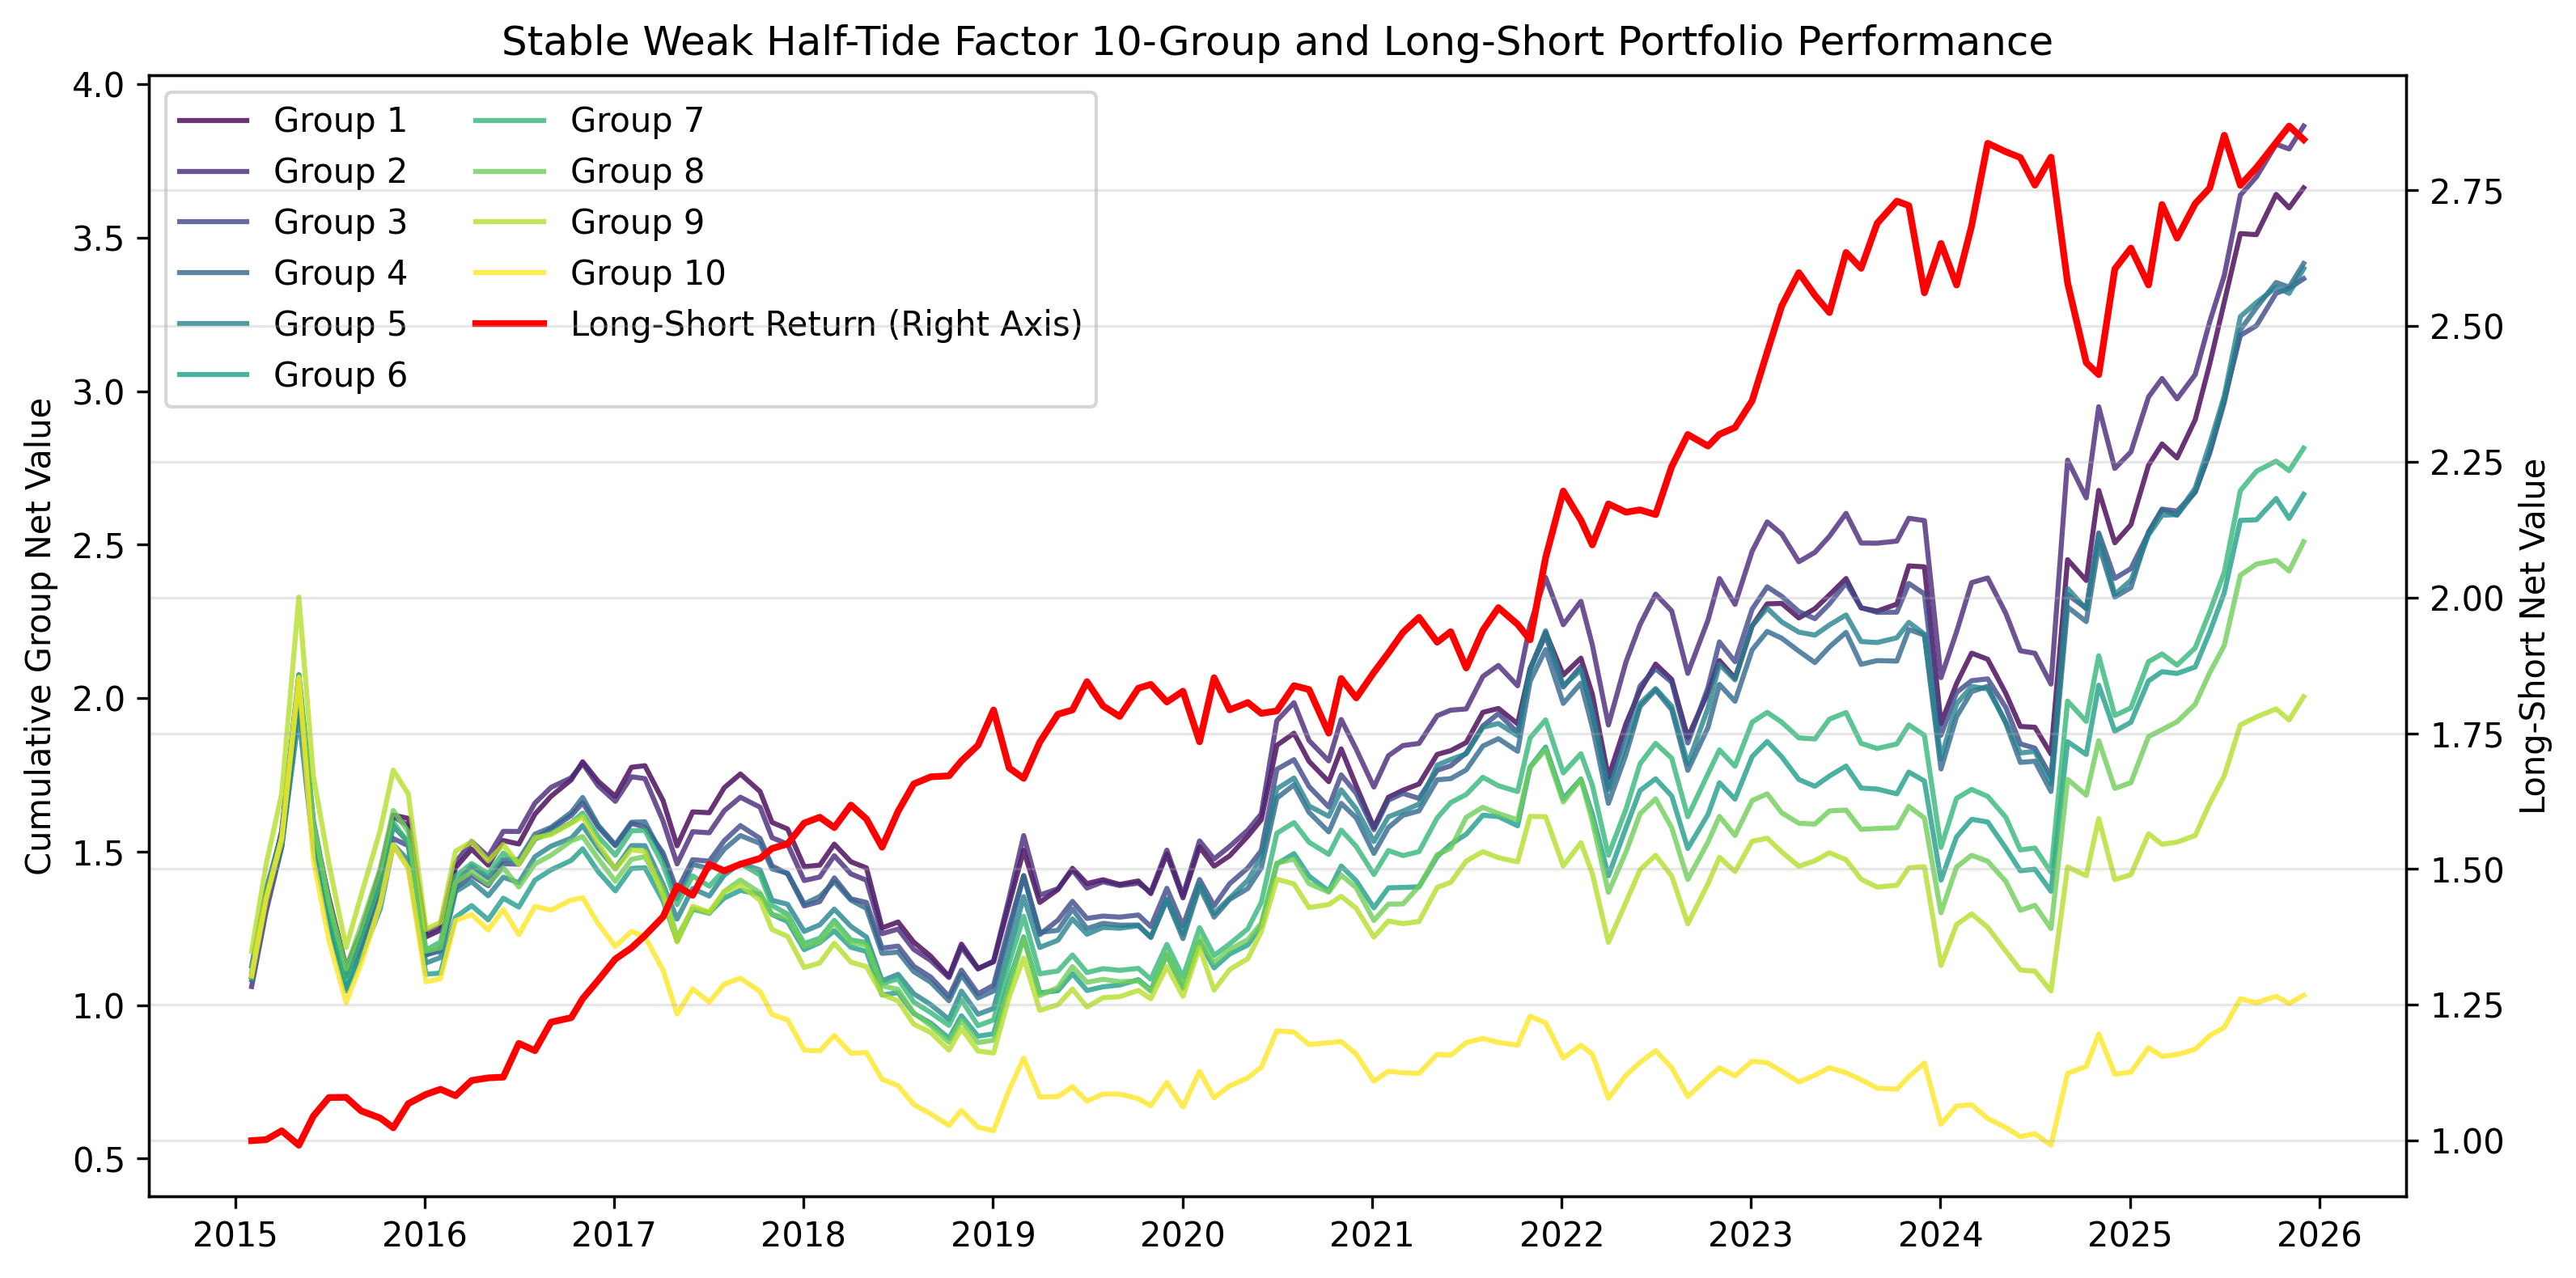

In [23]:
e3 = FactorBacktester(
    factor_aggressive_weak_half_tide_neutralized,
    stock_daily,
    factor_name='Aggressive Weak Half-Tide Factor'
)
e3.run() 

e4 = FactorBacktester(
    factor_stable_weak_half_tide_neutralized,
    stock_daily,
    factor_name='Stable Weak Half-Tide Factor'
)
e4.run() 

for e in [e3, e4]: 
    e.run()

summary = show_factor_metrics(e3, e4)
display(summary)

e3.plot_performance()
e4.plot_performance()

### Construction of the “Complete Tide” Factor

In the previous sections, we constructed several tide-related sub-factors by separately focusing on periods characterized by relatively high and relatively low investor trading enthusiasm. The empirical results indicate that the **Strong Half-Tide** factor performs particularly well during periods of heightened trading activity, while the **Aggressive Weak Half-Tide** factor exhibits strong performance during periods of relatively subdued trading.

Based on these findings, we further combine the two sub-factors with the most robust performance. Specifically, we construct the **“Complete Tide”** factor as an equally weighted combination of the **Strong Half-Tide** factor and the **Aggressive Weak Half-Tide** factor, thereby providing a comprehensive


In [24]:
# Ensure index alignment
common_dates = factor_strong_half_tide_neutralized.index.intersection(
    factor_aggressive_weak_half_tide_neutralized.index
)
common_stocks = factor_strong_half_tide_neutralized.columns.intersection(
    factor_aggressive_weak_half_tide_neutralized.columns
)

strong = factor_strong_half_tide_neutralized.loc[common_dates, common_stocks]
weak_aggressive = factor_aggressive_weak_half_tide_neutralized.loc[common_dates, common_stocks]

# Equally weighted combination to form the "complete tide" factor
factor_complete_tide = 0.5 * strong + 0.5 * weak_aggressive

In [25]:
factor_complete_tide

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,688802.SH,001325.SZ,688807.SH,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-02,NaN,NaN,0.287954,NaN,NaN,NaN,NaN,NaN,0.051071,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,NaN,NaN,0.266547,-0.947818,NaN,NaN,NaN,NaN,-0.018559,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-04,NaN,NaN,-0.156944,-0.854948,NaN,-0.302615,-0.518977,0.182960,0.257502,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-05,NaN,NaN,0.106575,NaN,-0.252758,-0.064303,NaN,0.346951,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05,NaN,0.435284,-0.575366,NaN,0.493533,-0.491536,-0.761420,-0.465708,0.727045,0.514443,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-06,0.022191,0.432369,-0.747831,-1.226576,0.194966,-0.122075,NaN,NaN,0.464711,0.679708,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-07,-0.060167,0.293497,-0.222522,NaN,NaN,NaN,-0.845005,NaN,0.175820,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Factor Name,Rank IC,Rank ICIR,t-value,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Maximum Drawdown
Complete Tide Factor,-6.47%,-1.16,-13.33,20.24%,8.40%,2.41,77.86%,6.48%


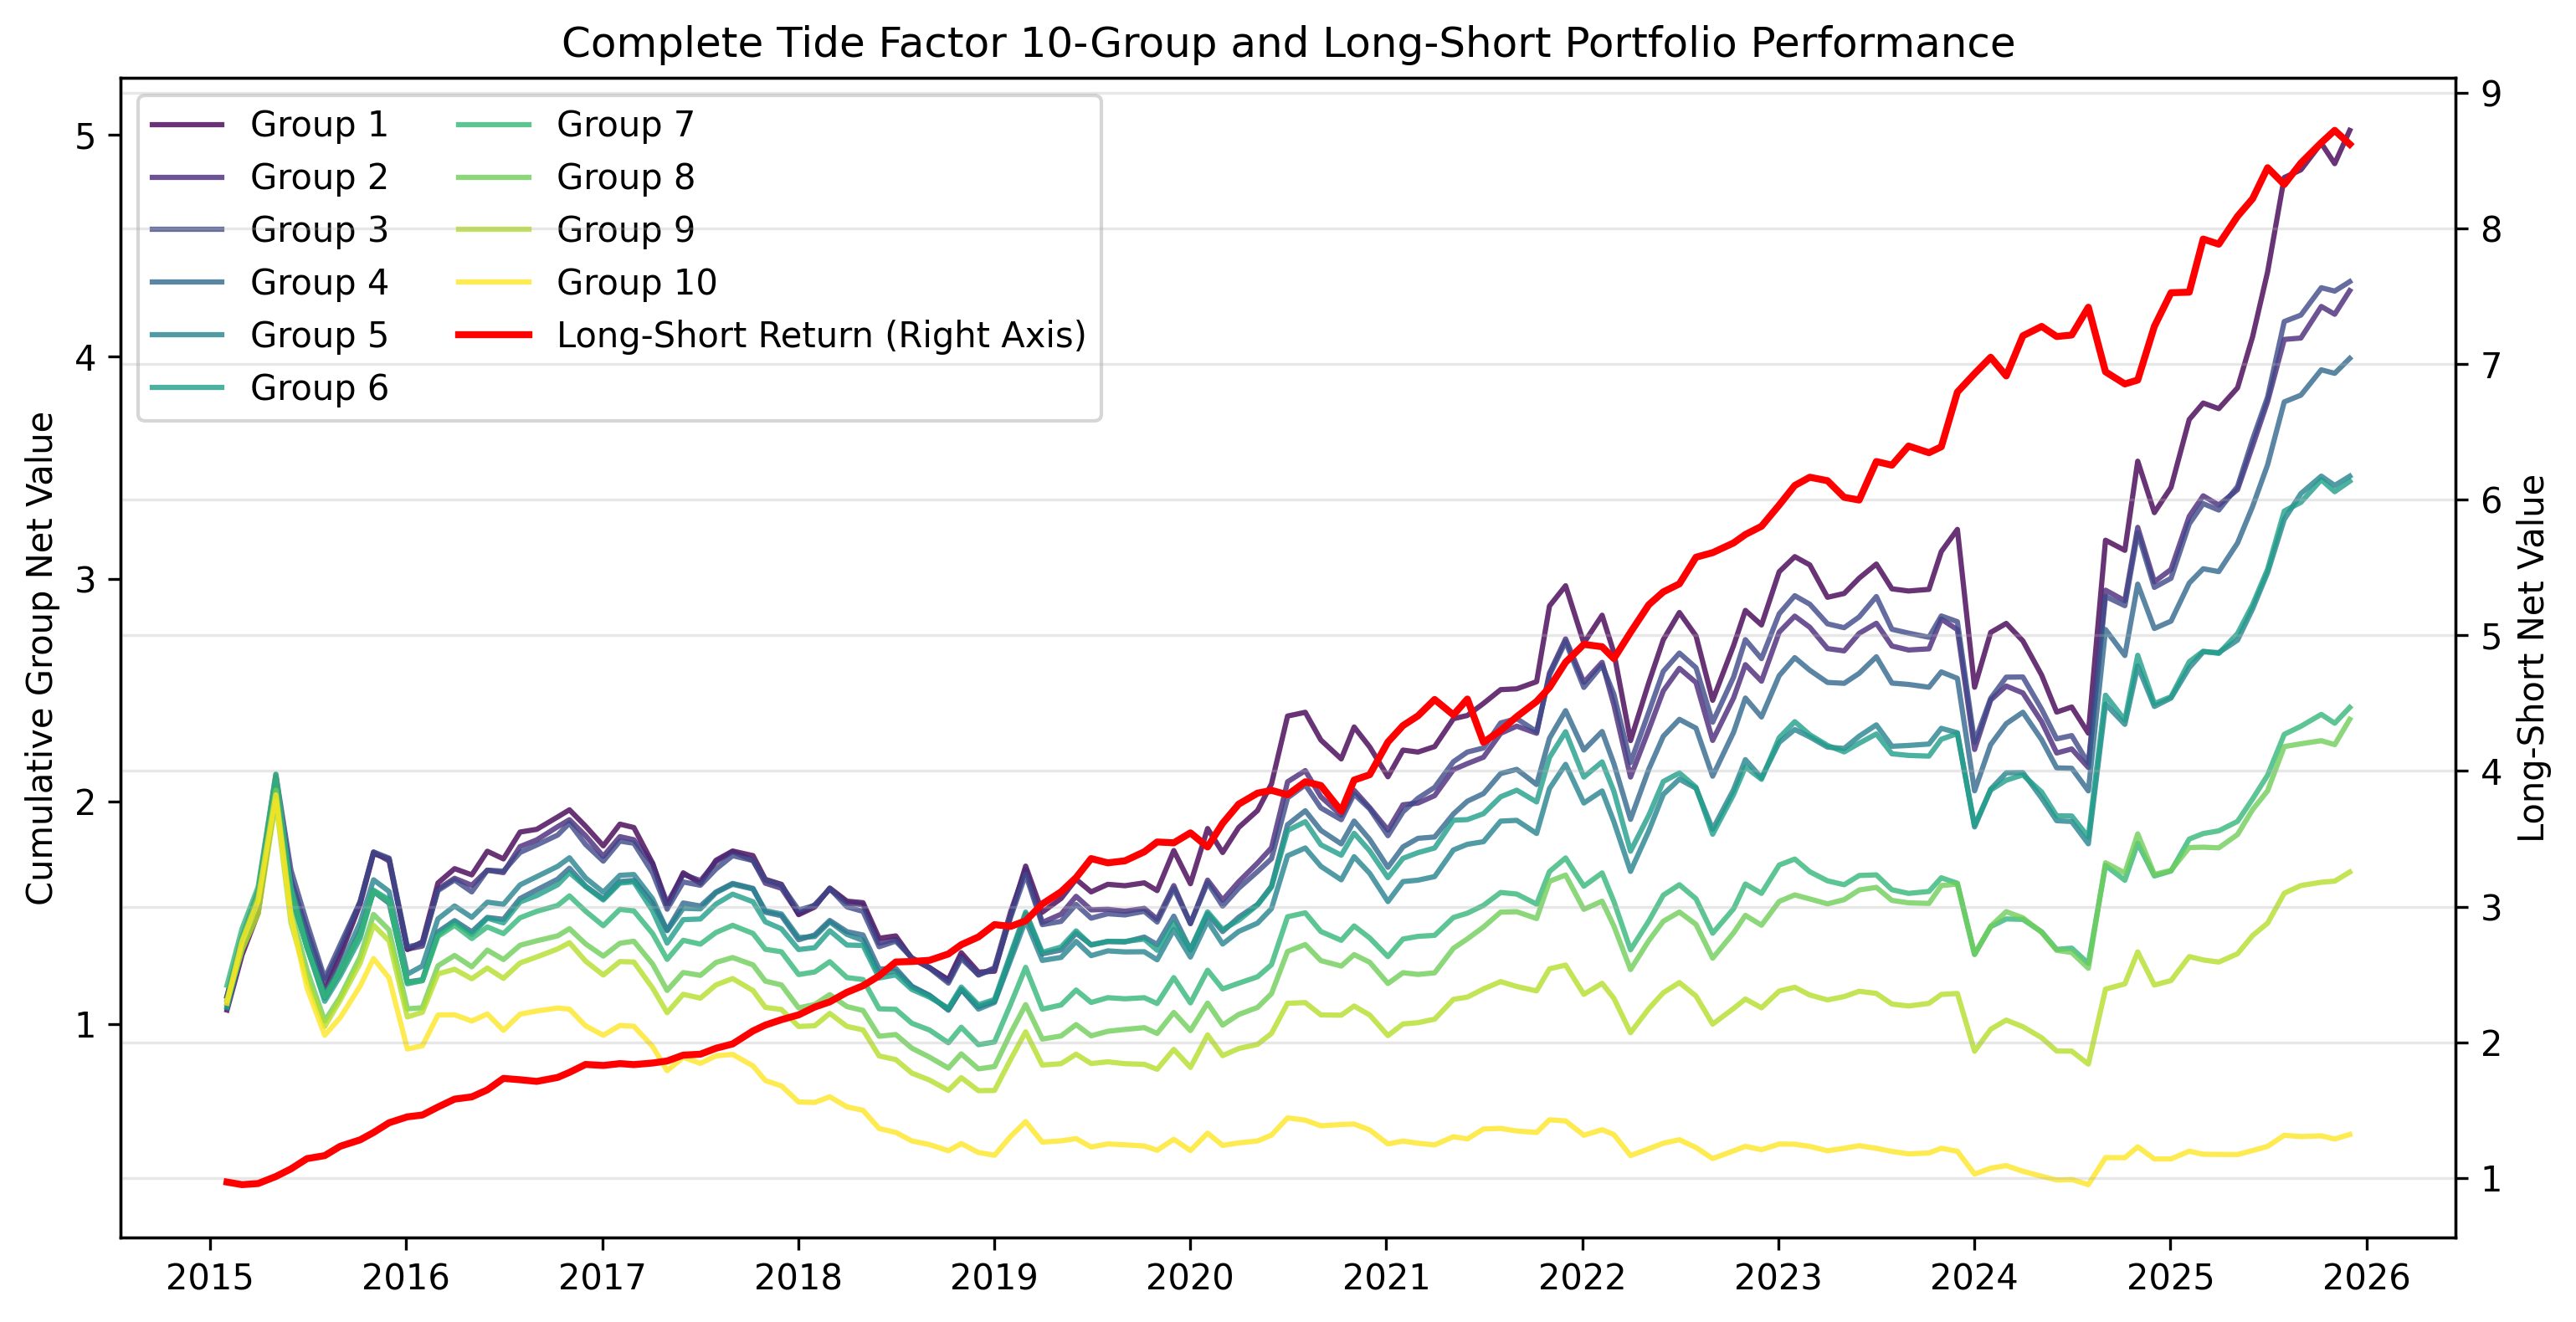

In [26]:
e5 = FactorBacktester(factor_complete_tide, stock_daily, factor_name='Complete Tide Factor')
e5.run() 

summary = show_factor_metrics(e5)
display(summary)

e5.plot_performance()